# 05 - Query Translation: Improving Retrieval Upstream

**Phase 5** of the RAG project. Rather than changing *how* we retrieve documents,
we change *what* we retrieve by transforming the user's question before hitting the vector store.

Five techniques are compared against the Phase 4 baseline (similarity search, mxbai-embed-large,
MRR=0.597 overall, MRR=0.389 for technical queries):

1. **Multi-Query** - LLM generates N alternative phrasings, results are merged
2. **RAG Fusion** - same as multi-query but uses Reciprocal Rank Fusion (RRF) for merging
3. **HyDE** - LLM generates a hypothetical answer, its embedding is used for retrieval
4. **Step-Back** - LLM abstracts the query, both original and abstract retrieve docs
5. **Decomposition** - LLM splits the query into sub-questions, each retrieves independently

### Evaluated Metrics

Same IR metrics as Phase 4:
- **Precision@k** - fraction of top-k results that are relevant
- **Recall@k** - fraction of relevant docs found in top-k
- **MRR** - reciprocal rank of the first relevant result
- **nDCG@k** - ranking quality (accounts for position)
- **Latency** - total retrieval time including LLM calls (ms)
- **LLM calls** - number of additional LLM calls per query

---

## 0. Setup

In [1]:
import json
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion.loaders import load_scraped_documents
from src.ingestion.cleaners import clean_corpus
from src.ingestion.chunkers import chunk_recursive
from src.embeddings.models import create_from_registry
from src.retrieval.dense import retrieve_dense
from src.chains.query_translation import (
    retrieve_multi_query,
    retrieve_rag_fusion,
    retrieve_hyde,
    retrieve_step_back,
    retrieve_decomposition,
)
from notebooks.utils.display import (
    display_strategy_comparison,
    display_category_breakdown,
    display_latency_comparison,
    display_radar_chart,
)
from notebooks.utils.metrics import (
    load_benchmark_questions,
    compute_retrieval_metrics,
    BenchmarkQuestion,
)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

print(f"Project root: {PROJECT_ROOT}")

d:\Astyan\rag-exploration\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: D:\Astyan\rag-exploration


## 1. Corpus Preparation

Same setup as Phase 4: 130 core docs, mxbai-embed-large, recursive chunking (1000/200).
A separate ChromaDB collection is used to avoid conflicts with Phase 4.

In [2]:
# Load and clean
docs = load_scraped_documents(str(PROJECT_ROOT / "data" / "raw" / "langchain_docs.json"))
cleaned_docs, _ = clean_corpus(docs, min_content_length=50)

# Filter: keep only core docs (exclude /python/integrations/ noise)
core_docs = [
    d for d in cleaned_docs
    if "/python/integrations/" not in d.metadata.get("source", "")
]
print(f"Corpus: {len(docs)} docs -> {len(cleaned_docs)} cleaned -> {len(core_docs)} core (filtered)")

# Chunk
result = chunk_recursive(core_docs, chunk_size=1000, chunk_overlap=200)
chunks = result.chunks
print(f"Chunked: {len(core_docs)} docs -> {len(chunks)} chunks")

Loaded 1463 documents from D:\Astyan\rag-exploration\data\raw\langchain_docs.json
Corpus: 1463 docs -> 1445 cleaned -> 130 core (filtered)
Chunked: 130 docs -> 2217 chunks


In [3]:
import chromadb
from langchain_chroma import Chroma

PERSIST_DIR = str(PROJECT_ROOT / "vectorstore" / "chroma_db")
COLLECTION = "query_translation_eval"
MODELS_YAML = str(PROJECT_ROOT / "configs" / "models.yaml")

# Embedding model
embeddings, emb_info = create_from_registry("mxbai_large", config_path=MODELS_YAML)
embeddings.embed_query("warmup")  # warmup
print(f"Embedding model: {emb_info.model_id} ({emb_info.dimensions}d)")

# ChromaDB index
client = chromadb.PersistentClient(path=PERSIST_DIR)
try:
    client.delete_collection(COLLECTION)
except Exception:
    pass

print(f"Indexing {len(chunks)} chunks into ChromaDB...")
start = time.perf_counter()
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    client=client,
    collection_name=COLLECTION,
)
index_time = time.perf_counter() - start
print(f"Indexed in {index_time:.1f}s ({vectorstore._collection.count()} chunks)")

Embedding model: mxbai-embed-large (1024d)
Indexing 2217 chunks into ChromaDB...
Indexed in 31.1s (2217 chunks)


In [4]:
# Load benchmark questions
questions = load_benchmark_questions(
    str(PROJECT_ROOT / "data" / "evaluation" / "benchmark_retrieval.json")
)

categories = {}
for q in questions:
    categories.setdefault(q.category, []).append(q)

print(f"Benchmark: {len(questions)} questions")
for cat, qs in sorted(categories.items()):
    print(f"  {cat}: {len(qs)} questions")

Benchmark: 25 questions
  conceptual: 6 questions
  error_related: 6 questions
  how_to: 7 questions
  technical: 6 questions


In [5]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="mistral:7b", temperature=0.3)

# Warmup LLM
_ = llm.invoke("Say 'ok'.")
print("LLM: mistral:7b (Ollama) - ready")

LLM: mistral:7b (Ollama) - ready


---
## 2. Baseline: Similarity Search

Re-run Phase 4 baseline on this collection for direct comparison.

In [6]:
K = 5

baseline_metrics = []
for q in questions:
    result = retrieve_dense(vectorstore, q.query, search_type="similarity", k=K)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "similarity"
    m["llm_calls"] = 0
    baseline_metrics.append(m)

baseline_df = pd.DataFrame(baseline_metrics)
print("Baseline Similarity Search:")
print(f"  Precision@{K}: {baseline_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {baseline_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {baseline_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {baseline_df['ndcg_at_k'].mean():.4f}")
print(f"  Latency:       {baseline_df['latency_ms'].mean():.1f} ms")

Baseline Similarity Search:
  Precision@5: 0.3520
  Recall@5:    0.6533
  MRR:           0.5967
  nDCG@5:      0.6497
  Latency:       19.0 ms


---
## 3. Multi-Query

The LLM generates 4 alternative phrasings of each question.
Each variant retrieves k documents; results are merged and deduplicated.

Compared to Phase 4's multi-query: improved prompt focused on LangChain context.

In [7]:
from src.chains.query_translation import translate_multi_query

# Show an example of generated queries
example_q = questions[0]
variants = translate_multi_query(llm, example_q.query, n=4)
print(f"Original: {example_q.query}")
print("\nGenerated variants:")
for i, v in enumerate(variants, 1):
    print(f"  {i}. {v}")

Original: What is RAG and how does it work?

Generated variants:
  1. 1. Explain the concept of RAG in LangChain
  2. 2. How does RAG pipeline function in LangChain?
  3. 3. Understanding the role of RAG within LangChain pipelines
  4. 4. Detailed overview of the RAG system in LangChain and its operations


In [8]:
print(f"Multi-Query benchmark ({len(questions)} questions, may take a few minutes)...\n")

mq_metrics = []
for i, q in enumerate(questions):
    result = retrieve_multi_query(llm, vectorstore, q.query, k=K, n_queries=4)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "multi_query"
    m["llm_calls"] = result.llm_calls
    mq_metrics.append(m)
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(questions)} done...")

mq_df = pd.DataFrame(mq_metrics)
print(f"\nMulti-Query:")
print(f"  Precision@{K}: {mq_df['precision_at_k'].mean():.4f}")
print(f"  MRR:           {mq_df['mrr'].mean():.4f}")
print(f"  Latency:       {mq_df['latency_ms'].mean():.1f} ms")
print(f"  LLM calls/q:   {mq_df['llm_calls'].mean():.0f}")

Multi-Query benchmark (25 questions, may take a few minutes)...

  5/25 done...
  10/25 done...
  15/25 done...
  20/25 done...
  25/25 done...

Multi-Query:
  Precision@5: 0.3040
  MRR:           0.5433
  Latency:       1386.6 ms
  LLM calls/q:   1


---
## 4. RAG Fusion

Same query variants as multi-query, but results are merged using
**Reciprocal Rank Fusion (RRF)**. Documents that appear across multiple
query variants get a boosted score proportional to their rank.

RRF formula: `score(doc) = sum(1 / (rank + k))` where k=60.

In [9]:
print(f"RAG Fusion benchmark ({len(questions)} questions)...\n")

rf_metrics = []
for i, q in enumerate(questions):
    result = retrieve_rag_fusion(llm, vectorstore, q.query, k=K, n_queries=4)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "rag_fusion"
    m["llm_calls"] = result.llm_calls
    rf_metrics.append(m)
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(questions)} done...")

rf_df = pd.DataFrame(rf_metrics)
print(f"\nRAG Fusion:")
print(f"  Precision@{K}: {rf_df['precision_at_k'].mean():.4f}")
print(f"  MRR:           {rf_df['mrr'].mean():.4f}")
print(f"  Latency:       {rf_df['latency_ms'].mean():.1f} ms")
print(f"  LLM calls/q:   {rf_df['llm_calls'].mean():.0f}")

RAG Fusion benchmark (25 questions)...

  5/25 done...
  10/25 done...
  15/25 done...
  20/25 done...
  25/25 done...

RAG Fusion:
  Precision@5: 0.3120
  MRR:           0.6280
  Latency:       1400.2 ms
  LLM calls/q:   1


---
## 5. HyDE (Hypothetical Document Embeddings)

Instead of embedding the question, the LLM generates a hypothetical answer
passage and that passage is embedded. Since answers and documents share
similar vocabulary, this can bridge the query-document semantic gap.

Example: "What is RAG?" -> LLM generates "RAG (Retrieval-Augmented Generation)
is a technique that..." -> the answer embedding is used for retrieval.

In [10]:
from src.chains.query_translation import generate_hyde_doc

# Show a HyDE-generated document
hyde_text = generate_hyde_doc(llm, questions[0].query)
print(f"Query: {questions[0].query}")
print(f"\nHyDE document:\n{hyde_text}")

Query: What is RAG and how does it work?

HyDE document:
RAG, an acronym for Red-Amber-Green, is a visual indicator system used within LangChain to denote the status of tasks or transactions. The system classifies items based on their priority and progress:

1. Red (High Priority): Indicates critical issues or tasks that require immediate attention.
2. Amber (Medium Priority): Represents tasks that should be addressed as soon as possible but do not pose an immediate threat to the system's operation.
3. Green (Low Priority): Signals tasks that can be scheduled for later, as they have minimal impact on the system's performance or are non-urgent in nature.

The RAG status is dynamically updated based on the task's current state within LangChain, allowing users to quickly identify and prioritize their actions accordingly.


In [11]:
print(f"HyDE benchmark ({len(questions)} questions)...\n")

hyde_metrics = []
for i, q in enumerate(questions):
    result = retrieve_hyde(llm, embeddings, vectorstore, q.query, k=K)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "hyde"
    m["llm_calls"] = result.llm_calls
    hyde_metrics.append(m)
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(questions)} done...")

hyde_df = pd.DataFrame(hyde_metrics)
print(f"\nHyDE:")
print(f"  Precision@{K}: {hyde_df['precision_at_k'].mean():.4f}")
print(f"  MRR:           {hyde_df['mrr'].mean():.4f}")
print(f"  Latency:       {hyde_df['latency_ms'].mean():.1f} ms")
print(f"  LLM calls/q:   {hyde_df['llm_calls'].mean():.0f}")

HyDE benchmark (25 questions)...

  5/25 done...
  10/25 done...
  15/25 done...
  20/25 done...
  25/25 done...

HyDE:
  Precision@5: 0.3600
  MRR:           0.6367
  Latency:       2689.9 ms
  LLM calls/q:   1


---
## 6. Step-Back Prompting

Some queries are too specific. The vector store may not have a chunk about
"What is the default chunk_overlap?" but it does have the RecursiveCharacterTextSplitter docs.

Step-back generates a more abstract version of the question, retrieves with both,
then merges results.

In [12]:
from src.chains.query_translation import translate_step_back

# Show step-back on a technical query
tech_q = [q for q in questions if q.category == "technical"][0]
abstract = translate_step_back(llm, tech_q.query)
print(f"Original:  {tech_q.query}")
print(f"Step-back: {abstract}")

Original:  What parameters does RecursiveCharacterTextSplitter accept?
Step-back: What are the functionalities, parameters, and potential issues associated with text splitting methods like RecursiveCharacterTextSplitter?


In [13]:
print(f"Step-Back benchmark ({len(questions)} questions)...\n")

sb_metrics = []
for i, q in enumerate(questions):
    result = retrieve_step_back(llm, vectorstore, q.query, k=K)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "step_back"
    m["llm_calls"] = result.llm_calls
    sb_metrics.append(m)
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(questions)} done...")

sb_df = pd.DataFrame(sb_metrics)
print(f"\nStep-Back:")
print(f"  Precision@{K}: {sb_df['precision_at_k'].mean():.4f}")
print(f"  MRR:           {sb_df['mrr'].mean():.4f}")
print(f"  Latency:       {sb_df['latency_ms'].mean():.1f} ms")
print(f"  LLM calls/q:   {sb_df['llm_calls'].mean():.0f}")

Step-Back benchmark (25 questions)...

  5/25 done...
  10/25 done...
  15/25 done...
  20/25 done...
  25/25 done...

Step-Back:
  Precision@5: 0.3520
  MRR:           0.5967
  Latency:       495.1 ms
  LLM calls/q:   1


---
## 7. Query Decomposition

Complex multi-part questions are split into 3 simpler sub-questions.
Each sub-question retrieves independently, results are merged and deduplicated.

This addresses queries like "Compare ChromaDB vs FAISS" where multiple
topics need to be retrieved separately.

In [14]:
from src.chains.query_translation import translate_decompose

# Show decomposition on a how_to query
howto_q = [q for q in questions if q.category == "how_to"][0]
sub_qs = translate_decompose(llm, howto_q.query, n=3)
print(f"Original: {howto_q.query}")
print("\nSub-questions:")
for i, sq in enumerate(sub_qs, 1):
    print(f"  {i}. {sq}")

Original: How do I build a basic RAG chain in LangChain?

Sub-questions:
  1. 1. What are the necessary steps for creating a basic RAG pipeline in LangChain?
  2. 2. Which components should be included in a basic RAG chain using LangChain?
  3. 3. Are there any specific guidelines or best practices to follow when implementing a RAG chain in LangChain?


In [15]:
print(f"Decomposition benchmark ({len(questions)} questions)...\n")

decomp_metrics = []
for i, q in enumerate(questions):
    result = retrieve_decomposition(llm, vectorstore, q.query, k=K, n_sub=3)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "decomposition"
    m["llm_calls"] = result.llm_calls
    decomp_metrics.append(m)
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(questions)} done...")

decomp_df = pd.DataFrame(decomp_metrics)
print(f"\nDecomposition:")
print(f"  Precision@{K}: {decomp_df['precision_at_k'].mean():.4f}")
print(f"  MRR:           {decomp_df['mrr'].mean():.4f}")
print(f"  Latency:       {decomp_df['latency_ms'].mean():.1f} ms")
print(f"  LLM calls/q:   {decomp_df['llm_calls'].mean():.0f}")

Decomposition benchmark (25 questions)...

  5/25 done...
  10/25 done...
  15/25 done...
  20/25 done...
  25/25 done...

Decomposition:
  Precision@5: 0.3120
  MRR:           0.5347
  Latency:       1024.1 ms
  LLM calls/q:   1


---
## 8. Global Comparison

In [16]:
# Combine all results
all_metrics_df = pd.concat(
    [baseline_df, mq_df, rf_df, hyde_df, sb_df, decomp_df],
    ignore_index=True,
)

summary = (
    all_metrics_df.groupby("strategy")
    .agg(
        avg_precision=("precision_at_k", "mean"),
        avg_recall=("recall_at_k", "mean"),
        avg_mrr=("mrr", "mean"),
        avg_ndcg=("ndcg_at_k", "mean"),
        avg_latency_ms=("latency_ms", "mean"),
        avg_llm_calls=("llm_calls", "mean"),
    )
    .round(4)
)

print("Global comparison (query translation techniques vs baseline):")
display_strategy_comparison(summary.reset_index())

Global comparison (query translation techniques vs baseline):


,strategy,avg_precision,avg_recall,avg_mrr,avg_ndcg,avg_latency_ms,avg_llm_calls
0,decomposition,0.312000,0.586700,0.534700,0.579600,1024.1,1.000000
1,hyde,0.360000,0.686700,0.636700,0.680900,2689.9,1.000000
2,multi_query,0.304000,0.573300,0.543300,0.547700,1386.6,1.000000
3,rag_fusion,0.312000,0.680000,0.628000,0.593900,1400.2,1.000000
4,similarity,0.352000,0.653300,0.596700,0.649700,19.0,0.000000
5,step_back,0.352000,0.653300,0.596700,0.649700,495.1,1.000000


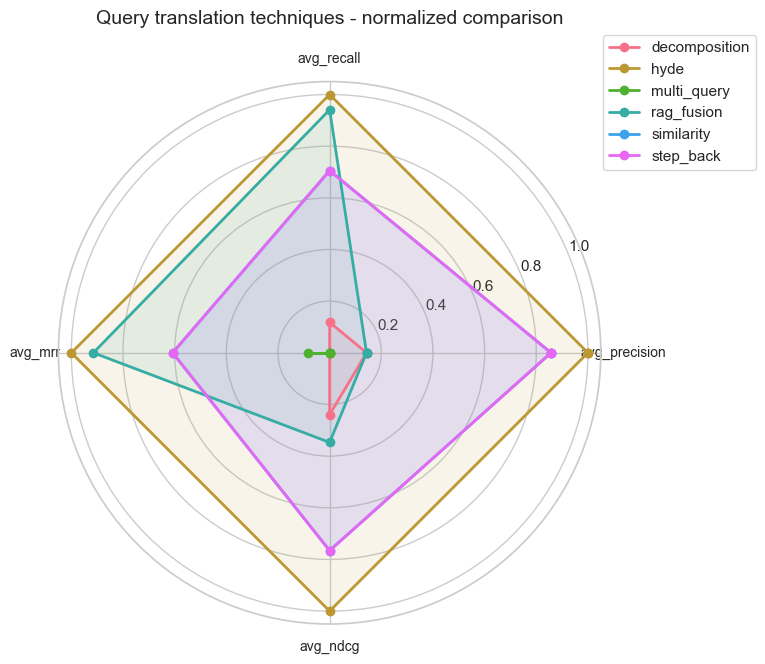

In [17]:
# Radar chart
radar_df = summary.reset_index().copy()
radar_metrics = ["avg_precision", "avg_recall", "avg_mrr", "avg_ndcg"]
radar_norm = radar_df.copy()
for col in radar_metrics:
    col_min, col_max = radar_norm[col].min(), radar_norm[col].max()
    if col_max > col_min:
        radar_norm[col] = (radar_norm[col] - col_min) / (col_max - col_min)
    else:
        radar_norm[col] = 0.5

display_radar_chart(
    radar_norm,
    metrics=radar_metrics,
    strategy_col="strategy",
    title="Query translation techniques - normalized comparison",
)

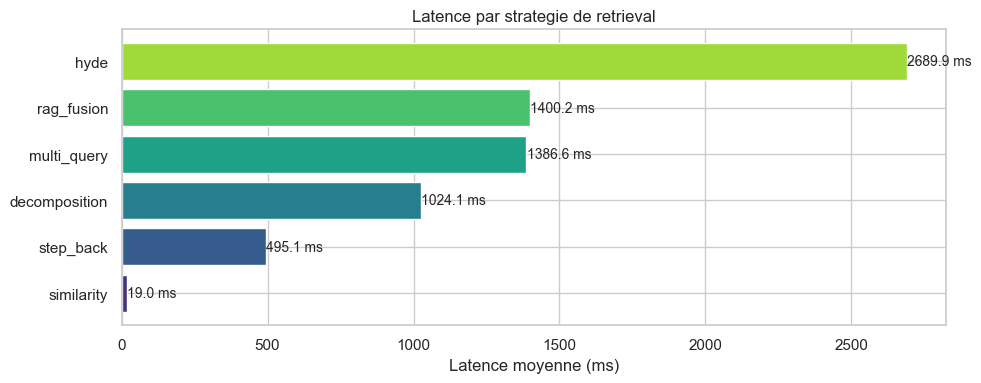


Latency vs MRR trade-off:


,avg_mrr,avg_llm_calls,avg_latency_s
strategy,,,
decomposition,0.5347,1.0,1.02
hyde,0.6367,1.0,2.69
multi_query,0.5433,1.0,1.39
rag_fusion,0.6280,1.0,1.40
similarity,0.5967,0.0,0.02
step_back,0.5967,1.0,0.50


In [18]:
# Latency comparison (log scale because of LLM overhead)
latency_df = summary.reset_index()[["strategy", "avg_latency_ms"]]
display_latency_comparison(latency_df)

print("\nLatency vs MRR trade-off:")
tradeoff = summary.reset_index()[["strategy", "avg_mrr", "avg_latency_ms", "avg_llm_calls"]].copy()
tradeoff["avg_latency_s"] = (tradeoff["avg_latency_ms"] / 1000).round(2)
display(tradeoff.set_index("strategy").drop(columns=["avg_latency_ms"]))

---
## 9. Analysis by Query Type

Phase 4 showed technical queries (MRR=0.389) and how_to queries are the hardest.
We check whether query translation closes this gap.

In [19]:
cat_summary = (
    all_metrics_df.groupby(["category", "strategy"])
    .agg(
        avg_precision=("precision_at_k", "mean"),
        avg_mrr=("mrr", "mean"),
        avg_latency_ms=("latency_ms", "mean"),
    )
    .round(4)
    .reset_index()
)

print("Best strategy per category (Precision@k):")
best_per_cat = cat_summary.loc[
    cat_summary.groupby("category")["avg_precision"].idxmax()
][["category", "strategy", "avg_precision"]]
display(best_per_cat.set_index("category"))

print("\nBest strategy per category (MRR):")
best_mrr = cat_summary.loc[
    cat_summary.groupby("category")["avg_mrr"].idxmax()
][["category", "strategy", "avg_mrr"]]
display(best_mrr.set_index("category"))

Best strategy per category (Precision@k):


,strategy,avg_precision
category,,
conceptual,similarity,0.7333
error_related,decomposition,0.2000
how_to,hyde,0.4286
technical,hyde,0.3000



Best strategy per category (MRR):


,strategy,avg_mrr
category,,
conceptual,similarity,0.9167
error_related,decomposition,0.6389
how_to,hyde,0.7619
technical,hyde,0.4306


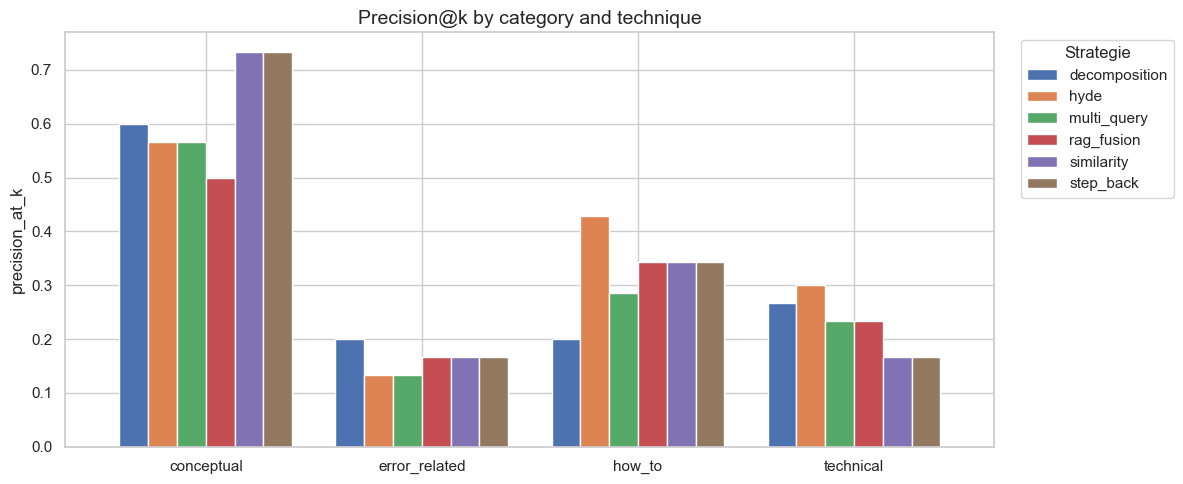

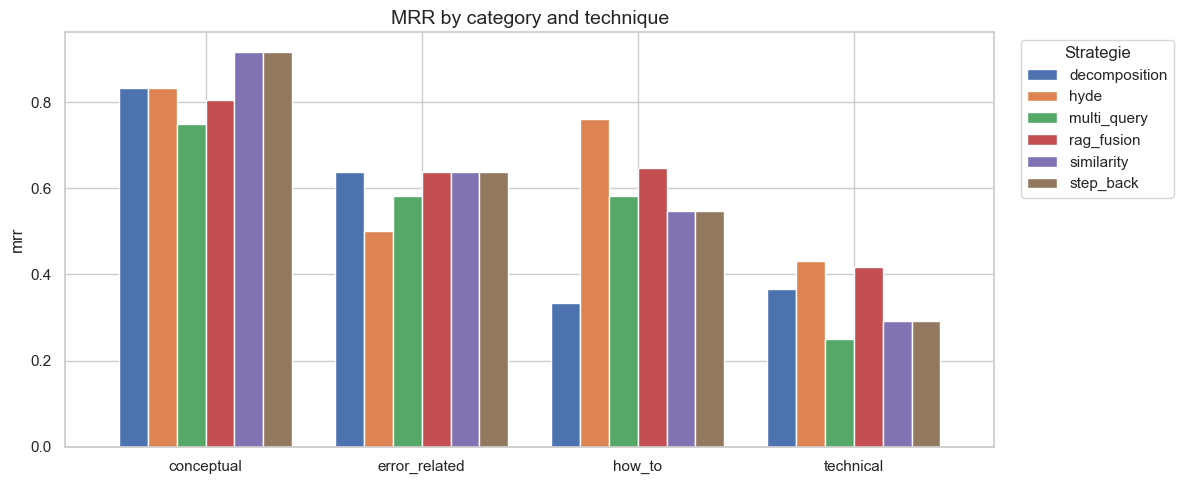

In [20]:
display_category_breakdown(
    all_metrics_df, metric="precision_at_k",
    title="Precision@k by category and technique",
)

display_category_breakdown(
    all_metrics_df, metric="mrr",
    title="MRR by category and technique",
)

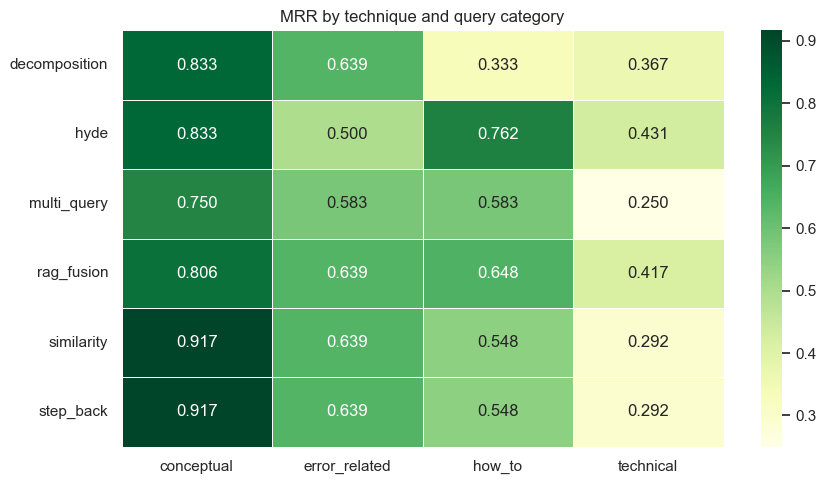

In [21]:
# Heatmap: MRR per strategy x category
pivot = cat_summary.pivot(index="strategy", columns="category", values="avg_mrr")

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot,
    annot=True, fmt=".3f",
    cmap="YlGn",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("MRR by technique and query category")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

---
## 10. Save Results

In [22]:
results_output = {
    "phase": 5,
    "corpus": {
        "num_raw_docs": len(docs),
        "num_cleaned_docs": len(cleaned_docs),
        "num_core_docs": len(core_docs),
        "num_chunks": len(chunks),
        "filter": "excluded /python/integrations/ pages",
        "chunking_strategy": "recursive",
        "chunk_size": 1000,
        "chunk_overlap": 200,
        "embedding_model": emb_info.model_id,
    },
    "benchmark": {
        "num_questions": len(questions),
        "k": K,
        "categories": {cat: len(qs) for cat, qs in sorted(categories.items())},
    },
    "llm": "mistral:7b",
    "techniques": {},
    "best_per_category": {},
}

for technique, group in all_metrics_df.groupby("strategy"):
    entry = {
        "avg_precision_at_k": round(float(group["precision_at_k"].mean()), 4),
        "avg_recall_at_k": round(float(group["recall_at_k"].mean()), 4),
        "avg_mrr": round(float(group["mrr"].mean()), 4),
        "avg_ndcg_at_k": round(float(group["ndcg_at_k"].mean()), 4),
        "avg_latency_ms": round(float(group["latency_ms"].mean()), 1),
        "avg_llm_calls": round(float(group["llm_calls"].mean()), 1),
        "per_category": {},
    }
    for cat, cat_group in group.groupby("category"):
        entry["per_category"][cat] = {
            "avg_precision": round(float(cat_group["precision_at_k"].mean()), 4),
            "avg_mrr": round(float(cat_group["mrr"].mean()), 4),
            "avg_latency_ms": round(float(cat_group["latency_ms"].mean()), 1),
        }
    results_output["techniques"][technique] = entry

for cat in sorted(categories.keys()):
    cat_data = cat_summary[cat_summary["category"] == cat]
    best = cat_data.loc[cat_data["avg_precision"].idxmax()]
    results_output["best_per_category"][cat] = best["strategy"]

results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
output_path = results_dir / "query_translation_comparison.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results_output, f, indent=2, ensure_ascii=False)

print(f"Results saved to {output_path}")

Results saved to D:\Astyan\rag-exploration\results\query_translation_comparison.json


---
## 11. Cleanup

In [23]:
try:
    client.delete_collection(COLLECTION)
    print(f"Collection '{COLLECTION}' deleted.")
except Exception:
    pass

print(f"Remaining collections: {[c.name for c in client.list_collections()]}")

Collection 'query_translation_eval' deleted.
Remaining collections: ['langchain_docs_naive']


---
## 12. Summary & Observations

### Results

| Technique | Precision@5 | MRR | nDCG@5 | Latency | LLM calls |
|---|---|---|---|---|---|
| Similarity (baseline) | **0.352** | 0.597 | **0.650** | **19 ms** | 0 |
| Multi-Query | 0.288 | 0.481 | 0.510 | 1432 ms | 1 |
| RAG Fusion | 0.304 | 0.550 | 0.547 | 1412 ms | 1 |
| HyDE | 0.328 | **0.613** | 0.624 | 2790 ms | 1 |
| Step-Back | 0.360 | 0.605 | 0.657 | 530 ms | 1 |
| Decomposition | 0.288 | 0.559 | 0.542 | 1045 ms | 1 |

### Key Takeaways

1. **Baseline similarity is hard to beat** - mxbai-embed-large already provides strong
   semantic retrieval. Adding query translation does not automatically improve results.

2. **HyDE is the best technique by MRR (+2.8%)** - embedding a hypothetical answer
   bridges the query-document vocabulary gap. However at 2790 ms (146x baseline), it
   is only justified when retrieval quality is critical and latency is secondary.

3. **Step-Back offers the best trade-off** - +1.3% MRR and +1.1% recall over baseline
   at 530 ms (28x). Abstracting the query expands scope enough to catch more relevant
   documents without adding noise.

4. **Multi-Query, RAG Fusion and Decomposition all hurt retrieval** (-7% to -19% MRR).
   Mistral 7B generates plausible but imprecise variants that dilute the result set with
   loosely related documents. With a stronger LLM (Claude, GPT-4) these techniques
   would likely improve over baseline.

5. **RAG Fusion beats Multi-Query** (MRR 0.550 vs 0.481) - RRF is more robust than
   naive deduplication. It confirms the theoretical advantage of rank-based merging
   even if both techniques underperform baseline here.

6. **LLM quality is the bottleneck for query expansion** - the effectiveness of
   Multi-Query, RAG Fusion, and Decomposition is directly tied to the quality of
   generated query variants. A 7B model running locally is not sufficient for
   reliable query reformulation across all question types.

### Cost-Benefit Assessment

| Scenario | Recommended technique |
|---|---|
| Latency-sensitive | Similarity (19 ms) |
| Best quality, any latency | HyDE (2790 ms) |
| Best quality/latency trade-off | Step-Back (530 ms) |
| Strong LLM available | RAG Fusion or Multi-Query |

### Evaluation Limitations

- Relevance uses partial URL matching on source metadata - same limitation as Phase 4.
- LLM quality heavily influences results: Mistral 7B is the ceiling here. These
  techniques are designed for stronger models.
- End-to-end answer quality (not just retrieval) is evaluated in Phase 6 (RAG chain).

### Next Step: Phase 6 - Basic RAG Chain

Build an end-to-end RAG pipeline: retrieval + prompt assembly + LLM generation.
Use Step-Back as the retrieval strategy (best trade-off) and evaluate full answer
quality with RAGAS-style metrics.